# Multiple feature Linear Regression

importing libraries:

In [1]:
try:
    
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    
except ModuleNotFoundError:
    %pip install numpy pandas matplotlib scikit-learn plotly


loading training set and testing set:

In [2]:

df_train = pd.read_csv('../content/sample_data/california_housing_train.csv')
df_test = pd.read_csv("../content/sample_data/california_housing_test.csv")


In [3]:
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


visualizing some of the data:

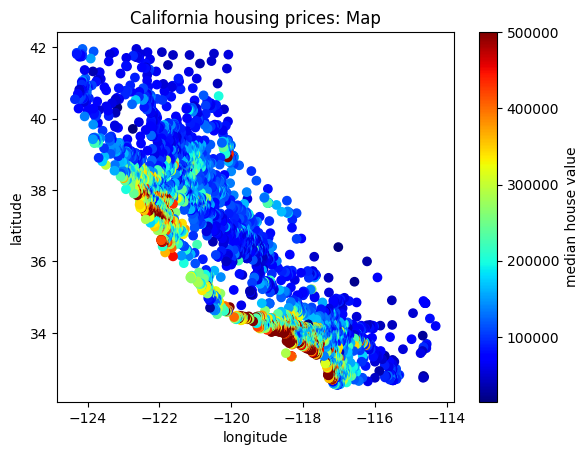

In [4]:
plt.scatter(df_train["longitude"], df_train["latitude"],
            c=df_train["median_house_value"], cmap="jet")
plt.title("California housing prices: Map")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar(label="median house value")
plt.show()

## Feature enginnering

feature engineering is the process of creating new features from the existing ones in order to improve the performance of a machine learning model. In this case, we can create new features such as "rooms_per_household" and "population_per_household" by dividing the total number of rooms and population by the number of households, respectively. This can help the model to better understand the relationship between these features and the target variable (median house value).


In [5]:

df_train["rooms_per_household"] = df_train["total_rooms"] / df_train["households"]
df_train["population_per_household"] = df_train["population"] / df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"] / df_train["total_rooms"]

df_test["rooms_per_household"] = df_test["total_rooms"] / df_test["households"]
df_test["population_per_household"] = df_test["population"] / df_test["households"]
df_test["bedrooms_per_room"] = df_test["total_bedrooms"] / df_test["total_rooms"]

In [6]:
X_train = df_train.drop(columns='median_income').to_numpy()
Y_train = df_train['median_income'].to_numpy()

X_test = df_test.drop(columns='median_income').to_numpy()
Y_test = df_test["median_income"].to_numpy()


normalizing the data:

In [7]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train = (X_train - mu)/ sigma
X_test = np.array(X_test)
X_test = (X_test - mu)/ sigma

the functions below are the same as the single linear regression ones, except for the parameter $w$, that now represents a vector

In [8]:

def compute_fwb(w, b, x):

  fwb = np.dot(x,w) + b
  return fwb

In [9]:
def compute_cost(x, y, w, b):

    m = x.shape[0]
    fwb = compute_fwb(w, b, x)
    cost = np.sum((fwb - y)**2)

    return cost / (2 * m)

In [10]:
def compute_partial_derivatives(x, y, w, b):
  dj_dw = np.array(w.shape)
  m = x.shape[0]
  
  fwb = compute_fwb(w, b, x)
  error = fwb - y
  dj_dw = np.dot(error, x) / m
  dj_db = np.sum(error) / m


  return dj_dw, dj_db


In [11]:
def compute_gd(alpha, x, y, w, b, iterations):
  cost_history = []
  last_cost = compute_cost(x, y, w, b)
  for i in range(iterations):
    dj_dw, dj_db = compute_partial_derivatives(x, y, w, b)
    tmp_w = w - alpha * dj_dw
    tmp_b = b - alpha * dj_db
    w = tmp_w
    b = tmp_b
    cost = compute_cost(x, y, w, b)
    cost_history.append(cost)
    if abs(last_cost - cost) < 1.0e-6:
      break
    last_cost = cost
    if i % (iterations//10) == 0:
      print(f"iteration {i} → cost {compute_cost(x, y, w, b)}\nw = {w}, b = {b}\n")

  plt.plot(range(len(cost_history)), cost_history)
  plt.ylabel("cost")
  plt.xlabel("iterations")

  return w, b


iteration 0 → cost 2.5728323851040105
w = [-1.47734305e-02 -7.66131062e-02 -1.10604589e-01  1.86405006e-01
 -1.28746043e-02 -6.08330206e-04  7.29248895e-03  6.60079286e-01
  3.02730476e-01 -9.37492251e-03 -5.89257962e-01], b = 1.94178905

running time 0.11341571807861328


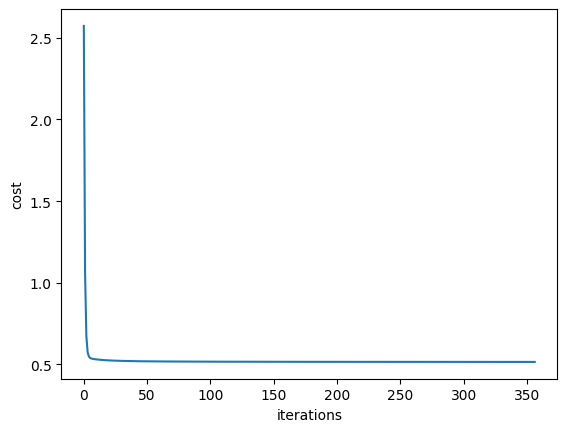

In [13]:
w_init = np.zeros(X_train.shape[1])
import time
tic = time.time()

w, b = compute_gd(0.5, X_train, Y_train, w_init, 0, 10000)
toc = time.time()
print("running time", toc - tic)

11
11 (11,) <class 'numpy.ndarray'>


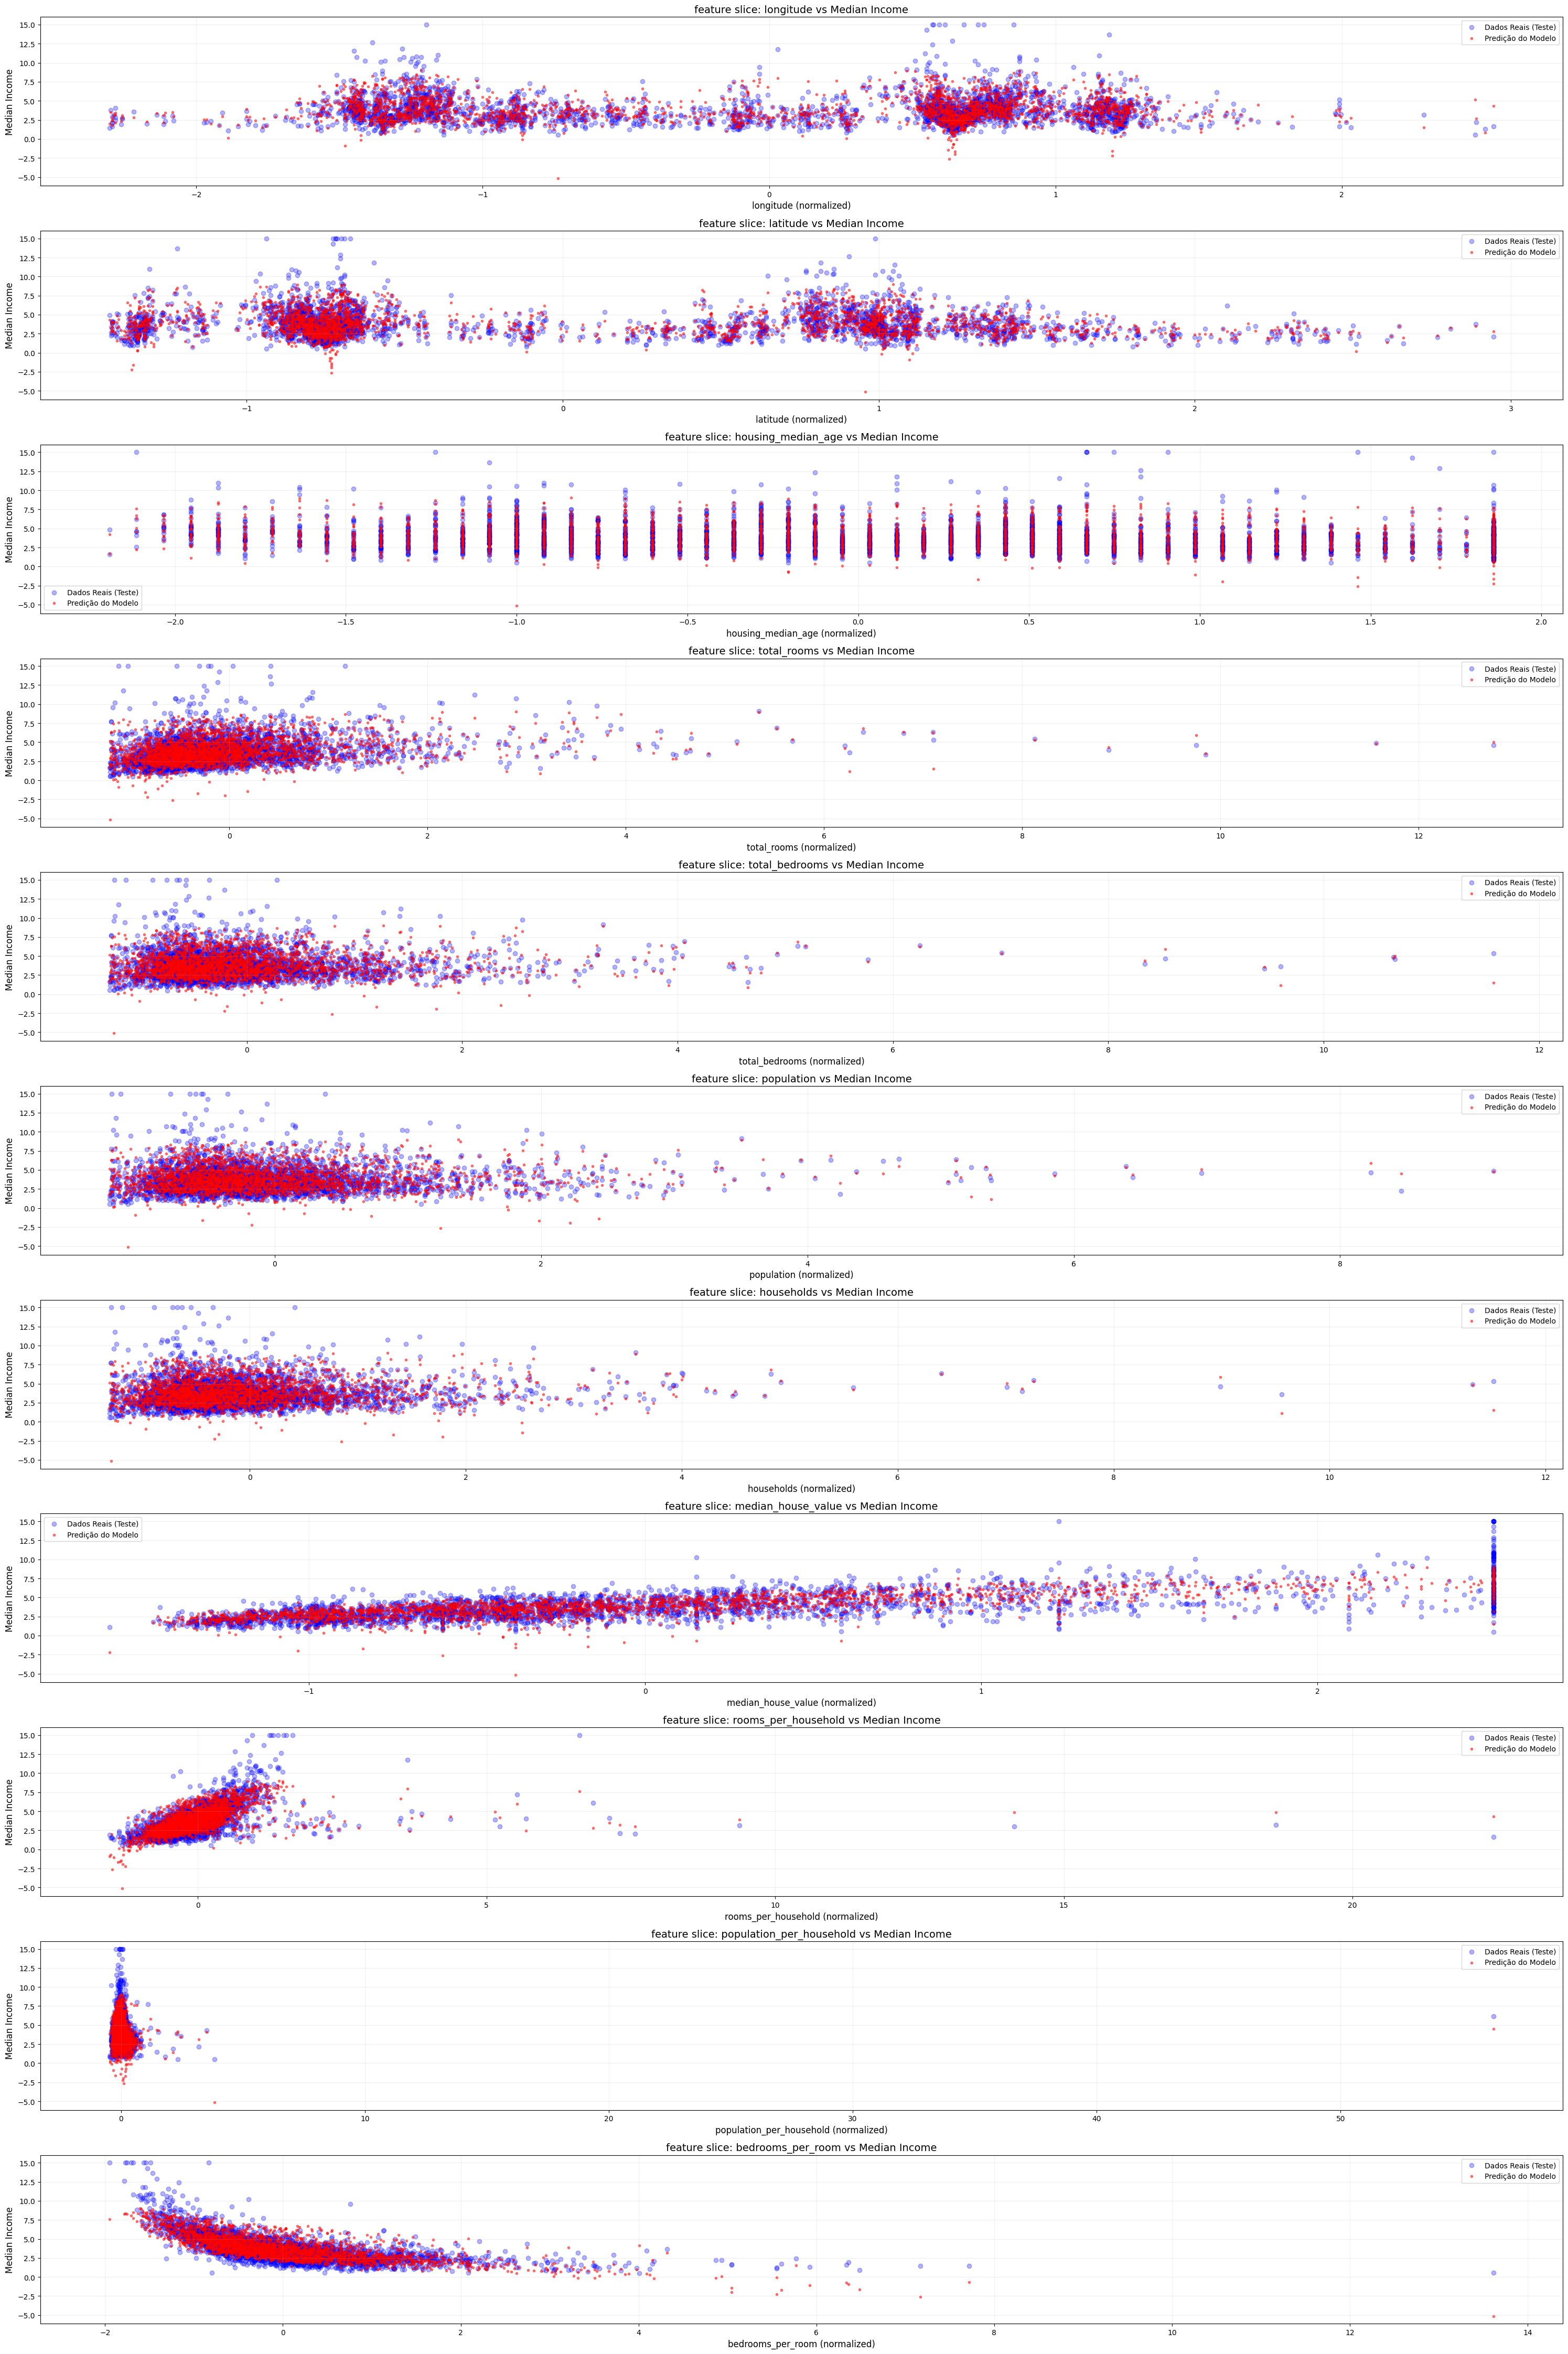

In [14]:
predictions = compute_fwb(w, b, X_test)

features_names = list(df_test.drop(columns='median_income').columns)
num_features = len(features_names)
print(num_features)
fig, axes = plt.subplots(num_features, 1, figsize=(30, 45))
print(num_features, axes.shape, type(axes))
for i in range(num_features):

    axes[i].scatter(X_test[:, i], Y_test,
                    color='blue', alpha=0.3, label='Dados Reais (Teste)')

    axes[i].scatter(X_test[:, i], predictions,
                    color='red', alpha=0.5, marker='.', label='Predição do Modelo')

    axes[i].set_title(f'feature slice: {features_names[i]} vs Median Income', fontsize=14)
    axes[i].set_xlabel(f'{features_names[i]} (normalized)', fontsize=12)
    axes[i].set_ylabel('Median Income', fontsize=12)
    axes[i].legend()
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

as the graph above shows, the model don't handle well the outliers.

the cell below allows you to test a single example from the test set

In [ ]:
import ipywidgets as widgets

def show_prediction(i):
    ieth_test_example = X_test[i, :]
    target_value = Y_test[i]

    test_prediction = compute_fwb(w, b, ieth_test_example)

    print(f"target: {target_value}")
    print(f"prediction: {test_prediction}")

widgets.interact(
    show_prediction,
    i=widgets.BoundedIntText(
        value=0,
        min=0,
        max=len(X_test)-1,
        step=1,
        description="Index:",
        
    )
)

interactive(children=(BoundedIntText(value=0, description='Index:', max=2999), Output()), _dom_classes=('widge…

<function __main__.show_prediction(i)>

In [16]:

def regression_metrics(y_true, y_pred):

    m = len(y_true)

    # Errors
    error = y_pred - y_true

    # MSE
    mse = np.mean(error**2)

    # RMSE
    rmse = np.sqrt(mse)

    # MAE
    mae = np.mean(np.abs(error))

    # R²
    ss_res = np.sum(error**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)

    # adjusted R² 
    n_features = X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (m - 1) / (m - n_features - 1)

    return mse, rmse, mae, r2, r2_adj


mse, rmse, mae, r2, r2_adj = regression_metrics(Y_test, predictions)

print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.6f}")
print(f"adjusted R²   : {r2_adj:.6f}")

MSE  : 1.025009
RMSE : 1.012427
MAE  : 0.683797
R²   : 0.701865
adjusted R²   : 0.700767
